In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


# Ejemplo sencillo de Autograd en Pytorch

Es un mecanismo que permite construir un grafo de los cómputos realizados por una red neuronal. Resulta útil para calcular las derivadas parciales de esos cómputos, las cuales se utilizan  al realizar la fase de backpropagation en un proceso de entrenamiento.

Existen varias formas de activar el mecanismo de autograd

* Al crear un tensor: usando el parámetro requires_grad=True

Durante la ejecución de los tensores se genera un DAG que refleja la computación

Al ejecutar la función *backward()* sobre la salida, se realiza el cálculo de los gradientes mediante las derivadas parciales

In [2]:
import torch

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Define a simple function: z = x^2 + y^3
z = x**2 + y**3

# Calculate gradients
z.backward()

# Access gradients
x_grad = x.grad
y_grad = y.grad

print("Gradient of x:", x_grad)
print("Gradient of y:", y_grad)

Gradient of x: tensor(4.)
Gradient of y: tensor(27.)


## Ejemplo Avanzado de Autograd en Pytorch





tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)
tensor([ 0.0000e+00,  2.5882e-01,  5.0000e-01,  7.0711e-01,  8.6603e-01,
         9.6593e-01,  1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,
         5.0000e-01,  2.5882e-01, -8.7423e-08, -2.5882e-01, -5.0000e-01,
        -7.0711e-01, -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01,
        -8.6603e-01, -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)


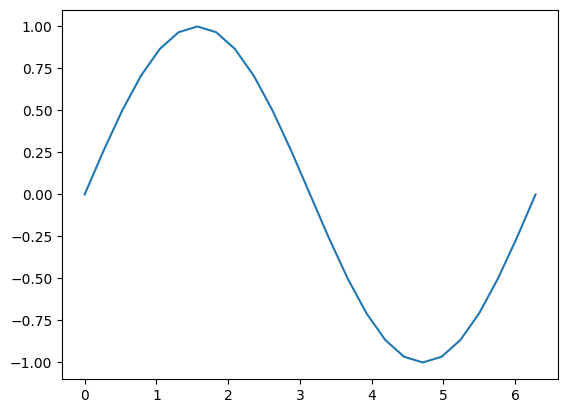

In [3]:
import torch

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
# Create a tensor and set requires_grad=True to track computation with it
# This tensor contains 25 elements from 0 to 2*pi
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
print(a)
# Create another tensor b from a appying sin function
b = torch.sin(a)
plt.plot(a.detach(), b.detach())
print(b)

La función grad_fn guarda una referencia indicando que cuando ejecutemos la backpropagation y computemos los gradientes, necesitaremos calcular la derivada de sin(x)

In [4]:
# Seguimos haciendo más cálculos encadenados
# Primero calculamos c = 2*b
c = 2 * b
print(c)
# Después calculamos d = c + 1
d = c + 1
print(d)
# Finalmente calculamos e = sum(d)
out = d.sum()
print(out)

tensor([ 0.0000e+00,  5.1764e-01,  1.0000e+00,  1.4142e+00,  1.7321e+00,
         1.9319e+00,  2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,
         1.0000e+00,  5.1764e-01, -1.7485e-07, -5.1764e-01, -1.0000e+00,
        -1.4142e+00, -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00,
        -1.7321e+00, -1.4142e+00, -1.0000e+00, -5.1764e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)
tensor([ 1.0000e+00,  1.5176e+00,  2.0000e+00,  2.4142e+00,  2.7321e+00,
         2.9319e+00,  3.0000e+00,  2.9319e+00,  2.7321e+00,  2.4142e+00,
         2.0000e+00,  1.5176e+00,  1.0000e+00,  4.8236e-01, -3.5763e-07,
        -4.1421e-01, -7.3205e-01, -9.3185e-01, -1.0000e+00, -9.3185e-01,
        -7.3205e-01, -4.1421e-01,  4.7684e-07,  4.8236e-01,  1.0000e+00],
       grad_fn=<AddBackward0>)
tensor(25., grad_fn=<SumBackward0>)


Vemos que cada tensor intermedio almacena una grad_fn que nos permitirá luego retroceder en el grafo de cómputos. 

En realidad, empezando en d, podemos retroceder en el grafo de los cómputos hasta llegar al tensor inicial a, donde dicho grafo llega a su raíz. 

In [5]:
print('d:')
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions)
print('\nc:')
print(c.grad_fn)
print('\nb:')
print(b.grad_fn)
print('\na:')
print(a.grad_fn)

d:
((<MulBackward0 object at 0x148fe4f51e10>, 0), (None, 0))
((<SinBackward0 object at 0x148fe4f52740>, 0), (None, 0))
((<AccumulateGrad object at 0x148fe4f53c40>, 0),)
()

c:

b:

a:
None


Hemos visto que el mecanismo de autograd construye un grafo de los cómputos que durante la backpropagation nos permitirá calcular las derivadas parciales. 

Para hacer uso de él debemos invocar la función backward sobre la salida final y, entonces, podremos ver el contenido de la propiedad ''grad'' de la entrada donde estarán los gradientes

In [ ]:
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
b = torch.sin(a)
c = 2 * b
d = c + 1
out = d.sum()
out.backward()
print(a.grad)
plt.plot(a.detach(), a.grad.detach())

Efectivamente, la derivada de 2*sin(a)+1 es 2*cos(a)    

## Autograd para entrenamiento

Definamos un pequeño modelo y examinemos cómo cambia después de un training batch.

In [7]:
BATCH_SIZE = 16
DIM_IN = 1000
HIDDEN_SIZE = 100
DIM_OUT = 10

# Definición del modelo
class TinyModel(torch.nn.Module):

# Definición de la arquitectura
    def __init__(self):
        super(TinyModel, self).__init__()
        # Una capa lineal que recibe 1000 dimensiones y devuelve 100
        self.layer1 = torch.nn.Linear(1000, 100)
        # Activación ReLU
        self.relu = torch.nn.ReLU()
        # Una capa lineal que recibe 100 dimensiones y devuelve 10
        self.layer2 = torch.nn.Linear(100, 10)
# Definición del forward
    def forward(self, x):
        # Primero pasamos por la capa 1 y luego por la ReLU
        x = self.layer1(x)
        x = self.relu(x)
        # Finalmente pasamos por la capa 2
        x = self.layer2(x)
        return x

# Generando datos de entrada y salida (deseada) de forma aleatoria
some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)

# Instanciando el modelo
model = TinyModel()
# Inspeccionamos algunos parámetros del modelo (un pequeño fragmento)
print(model.layer2.weight[0][0:10]) 
print(model.layer2.weight.grad)

tensor([-0.0024,  0.0365,  0.0569, -0.0053, -0.0814, -0.0067, -0.0171,  0.0147,
        -0.0482,  0.0804], grad_fn=<SliceBackward0>)
None


Ahora vamos a visualizar cómo cambia el contenido de estos parámetros cuando sometemos a la red a un proceso de entrenamiento

In [8]:
# Definimos un optimizador (SGD) y una función de pérdida (MSE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
prediction = model(some_input)
loss = (ideal_output - prediction).pow(2).sum()
print(loss)
# Calculamos los gradientes a través de la función backward 
# e imprimimos los mismo gradientes de la capa 2 que antes (para observar si han cambiado)
loss.backward()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor(149.1851, grad_fn=<SumBackward0>)
tensor([-0.0024,  0.0365,  0.0569, -0.0053, -0.0814, -0.0067, -0.0171,  0.0147,
        -0.0482,  0.0804], grad_fn=<SliceBackward0>)
tensor([ -4.2850,  -7.6359,  -2.8543,  -0.3781, -10.7992,  -2.5500,   3.5136,
         -6.3694,  -3.7701,  -1.8691])


Vemos que se han computado los gradientes pero no se han modificado los parámetros (pesos)
Para que suceda debemos ejecutar el optimizador

In [9]:
# Actualizamos los parámetros del modelo con los gradientes calculados
optimizer.step()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])
# Se reinician los gradientes para evitar que se acumulen en cada paso de entrenamiento
optimizer.zero_grad()

tensor([ 0.0019,  0.0441,  0.0598, -0.0050, -0.0706, -0.0042, -0.0206,  0.0211,
        -0.0444,  0.0823], grad_fn=<SliceBackward0>)
tensor([ -4.2850,  -7.6359,  -2.8543,  -0.3781, -10.7992,  -2.5500,   3.5136,
         -6.3694,  -3.7701,  -1.8691])


Un entrenamiento completo debe ejecutar este proceso de forma repetida

In [10]:
# print(model.layer2.weight.grad[0][0:10])

for i in range(0, 5):
    prediction = model(some_input)
    loss = (ideal_output - prediction).pow(2).sum()
    loss.backward()

print(model.layer2.weight.grad[0][0:10])

optimizer.zero_grad(set_to_none=False)

print(model.layer2.weight.grad[0][0:10])

tensor([ -9.0227, -24.8132, -15.9525,   2.6408, -25.9044,  -1.6590,  17.8436,
         -8.9751, -14.7646, -18.6171])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


El mecanismo de autograd se puede habilitar y deshabilitar para cada tensor individual utilizando el campo requires_grad

In [11]:
a = torch.ones(2, 3, requires_grad=True)
print(a)
# Con autograd activado
b1 = 2 * a
print(b1)
# Con autograd desactivado
a.requires_grad = False
b2 = 2 * a
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


También podemos desactivar autograd en un fragmento del código usando "with torch.no_grad():"

In [12]:
a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

# Primera operación con autograd activado
c1 = a + b
print(c1)

# Segunda operación con autograd desactivado
with torch.no_grad():
    c2 = a + b

print(c2)

# Versión alternativa con autograd activado
c3 = a * b
print(c3)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)


Algunas cuestiones adicionales:

Se puede usar torch.no_grad como un decorador de una función "@torch.no_grad()

No es correcto usar operaciones in_place con autograd, pues se sobrescribe la información de autograd y el cálculo
no sería el esperado

## Profiling de Autograd

El mecanismo de autograd tiene un profiler asociado que nos permite comprobar la evolución de la computación junto al tiempo de ejecución

In [13]:
device = torch.device('cpu')
run_on_gpu = False
if torch.cuda.is_available():
    device = torch.device('cuda')
    run_on_gpu = True

x = torch.randn(2, 3, requires_grad=True)
y = torch.rand(2, 3, requires_grad=True)
z = torch.ones(2, 3, requires_grad=True)

with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:
    for _ in range(1000):
        z = (z / x) * y

print(prf.key_averages().table(sort_by='self_cpu_time_total'))



STAGE:2024-02-13 07:33:53 1375312:1375312 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2024-02-13 07:33:53 1375312:1375312 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2024-02-13 07:33:53 1375312:1375312 ActivityProfilerController.cpp:324] Completed Stage: Post Processing


------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                     cudaEventRecord        33.19%       4.254ms        33.19%       4.254ms       1.063us       0.000us         0.00%       0.000us       0.000us          4000  
                           aten::div        26.45%       3.391ms        26.45%       3.391ms       3.391us       7.514ms        50.97%       7.514ms       7.514us          1000  
                           aten::mul        22.86%       2.930ms        22.86%       2.930ms       2.930

# Ejercicio 1

Quita los comentarios y completa las partes relevantes siguiendo las indicaciones


In [2]:
# Importamos PyTorch
import torch

# -----------------------------------------------------------
# Uso Básico de Autograd
# -----------------------------------------------------------
# Crea un tensor de tamaño 1x1 con el valor 5 y establece `requires_grad=True` para permitir el seguimiento de computación.

# ESCRIBE TU CÓDIGO AQUÍ
x = torch.tensor([5.0], requires_grad=True)

# Define una operación de tensor, por ejemplo, y = x^2.

# ESCRIBE TU CÓDIGO AQUÍ
y = x**2

# Imprime el gradiente de `x` (debería ser None porque aún no hemos llamado a `backward()`).

print(x.grad)

# Usa backward() para calcular los gradientes.

# ESCRIBE TU CÓDIGO AQUÍ

y.backward()

# Imprime el gradiente de `x` (debería ser 10 porque dy/dx = 2*x y x es 5).

print(x.grad)

# -----------------------------------------------------------
# Uso Avanzado de Autograd
# -----------------------------------------------------------
# Crea dos tensores `a` y `b` con los valores 2 y 3, respectivamente, y establece `requires_grad=True`.

# ESCRIBE TU CÓDIGO AQUÍ
a =  torch.tensor(2.0,requires_grad=True)
b = torch.tensor(3.0,requires_grad=True)


# Define una nueva operación tensorial, por ejemplo, c = a^2 + b^3.

# ESCRIBE TU CÓDIGO AQUÍ
c = a**2+ b**3


# Usa backward() para calcular los gradientes.


# ESCRIBE TU CÓDIGO AQUÍ
c.backward()
# Imprime los gradientes de `a` y `b`.

print(a.grad)  # Debería ser 4 porque dc/da = 2*a y a es 2.
print(b.grad)  # Debería ser 27 porque dc/db = 3*b^2 y b es 3.



None
tensor([10.])
tensor(4.)
tensor(27.)


# Ejercicio 2

Quita los comentarios y completa las partes relevantes siguiendo las indicaciones


In [4]:
# -*- coding: utf-8 -*-
"""
PyTorch: Tensors and autograd
-------------------------------

A third order polynomial, trained to predict :math:`y=\sin(x)` from :math:`-\pi`
to :math:`\pi` by minimizing squared Euclidean distance.

This implementation computes the forward pass using operations on PyTorch
Tensors, and uses PyTorch autograd to compute gradients.


A PyTorch Tensor represents a node in a computational graph. If ``x`` is a
Tensor that has ``x.requires_grad=True`` then ``x.grad`` is another Tensor
holding the gradient of ``x`` with respect to some scalar value.
"""
import torch
import math

dtype = torch.float
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

# Create Tensors to hold input and outputs.
# By default, requires_grad=False, which indicates that we do not need to
# compute gradients with respect to these Tensors during the backward pass.
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
y = torch.sin(x)

# Create random Tensors for weights. For a third order polynomial, we need
# 4 weights: y = a + b x + c x^2 + d x^3
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)

learning_rate = 1e-6
for t in range(2000):
    # Forward pass: compute predicted y using operations on Tensors.

    # Computa la expresión y = a + b x + c x^2 + d x^3
    # ESCRIBE TU CÓDIGO AQUÍ
    y_pred = a+b+c*(x**2)+d*(x**3)

    # Compute and print loss using operations on Tensors.
    # Now loss is a Tensor of shape (1,)
    #loss.item() gets the scalar value held in the loss.
    # Calcula la pérdida cuadrática media entre y_pred y y
    # ESCRIBE TU CÓDIGO AQUÍ

    loss = ((y_pred - y) ** 2).sum()

    if t % 100 == 99:
        print(t, loss.item())

    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Tensors with requires_grad=True.
    # After this call a.grad, b.grad. c.grad and d.grad will be Tensors holding
    # the gradient of the loss with respect to a, b, c, d respectively.
    loss.backward()

    # Manually update weights using gradient descent. Wrap in torch.no_grad()
    # because weights have requires_grad=True, but we don't need to track this
    # in autograd.
    with torch.no_grad():
        a -= learning_rate * a.grad
        # Recalcula b, c y d de forma similar a a
        # ESCRIBE TU CÓDIGO AQUÍ
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad      
        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

# Solución: https://github.com/pytorch/tutorials/blob/main/beginner_source/examples_autograd/polynomial_autograd.py

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22432/63578059.py:6: SyntaxWarning: invalid escape sequence '\s'
  A third order polynomial, trained to predict :math:`y=\sin(x)` from :math:`-\pi`


99 1577.8726806640625
199 1188.46630859375
299 989.6658935546875
399 888.174072265625
499 836.35986328125
599 809.9076538085938
699 796.4033203125
799 789.5089111328125
899 785.9892578125
999 784.1924438476562
1099 783.2750244140625
1199 782.8067016601562
1299 782.567626953125
1399 782.4456176757812
1499 782.38330078125
1599 782.3514404296875
1699 782.335205078125
1799 782.3270263671875
1899 782.32275390625
1999 782.3204956054688
Result: y = -0.8138027191162109 + 0.8122174739837646 x + 0.00027944493922404945 x^2 + 0.028076613321900368 x^3
